# Load data

In [1]:
import numpy as np
import pandas as pd
import torch
from Models import ModelConfig, \
    LinearRegressor, PolynomialRegressor, KNNRegressor, SVMRegressor, \
    DTRegressor, RFRegressor, GBRegressor, ABRegressor, XGBRegressor, LightGBMRegressor, \
    RealMLPRegressor, ResnetRegressor, FTTransformerRegressor
from sklearn.preprocessing import StandardScaler

print("torch:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

torch: 2.9.1
MPS built: True
MPS available: True


In [2]:
file_name = "CASP"
split_type = "Random_Split"

In [3]:
scaler = StandardScaler()

train_path = f"../data/splitted/{file_name}/{split_type}/train_0.parquet"
df_train = pd.read_parquet(train_path)

df_train = pd.DataFrame(
    scaler.fit_transform(df_train),
    columns = df_train.columns
)

test_path = f"../data/splitted/{file_name}/{split_type}/test_0.parquet"
df_test = pd.read_parquet(test_path)

df_test = pd.DataFrame(
    scaler.transform(df_test),
    columns = df_test.columns
)

In [4]:
config = ModelConfig(
    use_optim = True,
    metric = "rmse",
    n_splits = 3,
    seed = 42
)

# Linear Regression with Huber Loss

In [ ]:
regressor = LinearRegressor(df_train, df_test, config = config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# Polynomial Regression

In [ ]:
regressor = PolynomialRegressor(df_train, df_test, config = config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# K-Neareast Neighbours Regressor

In [ ]:
regressor = KNNRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# SVM Regressor

In [ ]:
regressor = SVMRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# Decision Tree Regressor

In [ ]:
regressor = DTRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# Random Forest Regressor

In [ ]:
regressor = RFRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# Gradient Boosting Regressor

In [ ]:
regressor = GBRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# AdaBoost Regressor

The estimator used is Decision Tree, we will optimize hyperparameters of both the estimator and AdaBoost

In [ ]:
regressor = ABRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# XGBoost Regressor

In [ ]:
regressor = XGBRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# LightGBM Regressor

In [ ]:
config.use_optim = False

In [ ]:
regressor = LightGBMRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# RealMLP Regressor

In [ ]:
config.use_optim = False
regressor = RealMLPRegressor(df_train, df_test, config)

In [ ]:
regressor.fit()

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# ResNet Regressor

In [ ]:
config.use_optim = False
regressor = ResnetRegressor(df_train, df_test, config, d_in = df_train.shape[1] - 1)

In [ ]:
regressor.fit(plot_train_progress = True)

In [ ]:
regressor.evaluate()

In [ ]:
regressor.sketch_model()

# FT-Transformer Regressor

In [5]:
config.use_optim = False
regressor = FTTransformerRegressor(
    df_train, df_test, config, 
    d_in = df_train.shape[1] - 1,
    n_blocks = 4
)


EPOCH 10:	Training loss: 0.635	Validation loss: 1.476

EPOCH 20:	Training loss: 0.561	Validation loss: 1.534

EPOCH 30:	Training loss: 0.515	Validation loss: 1.594

EPOCH 40:	Training loss: 0.498	Validation loss: 1.594

EPOCH 50:	Training loss: 0.467	Validation loss: 1.646

EPOCH 60:	Training loss: 0.436	Validation loss: 1.644

EPOCH 70:	Training loss: 0.420	Validation loss: 1.715

EPOCH 80:	Training loss: 0.404	Validation loss: 1.692

EPOCH 90:	Training loss: 0.383	Validation loss: 1.681

EPOCH 100:	Training loss: 0.374	Validation loss: 1.715


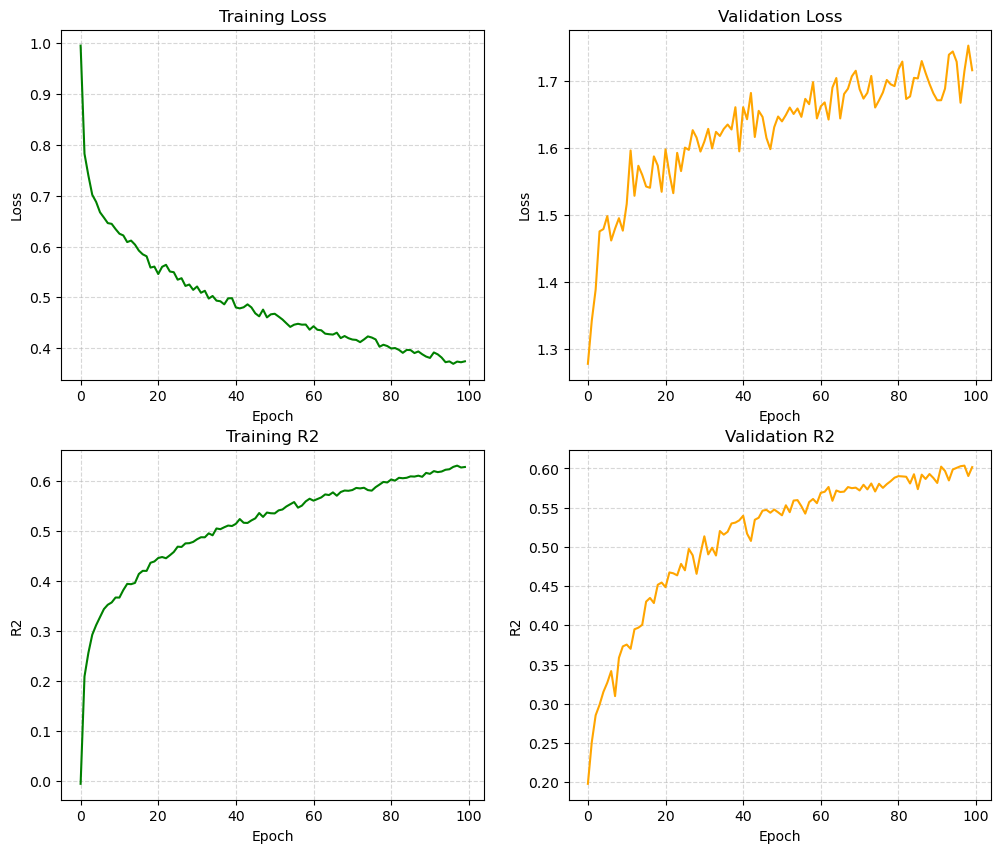

In [6]:
regressor.fit(plot_train_progress = True)

In [7]:
regressor.evaluate()

{'MSE': 0.38655832218257136,
 'RMSE': np.float64(0.6217381459928056),
 'MAE': 0.42957233219989854,
 'Adjusted R2 score': 0.6108303207713922}

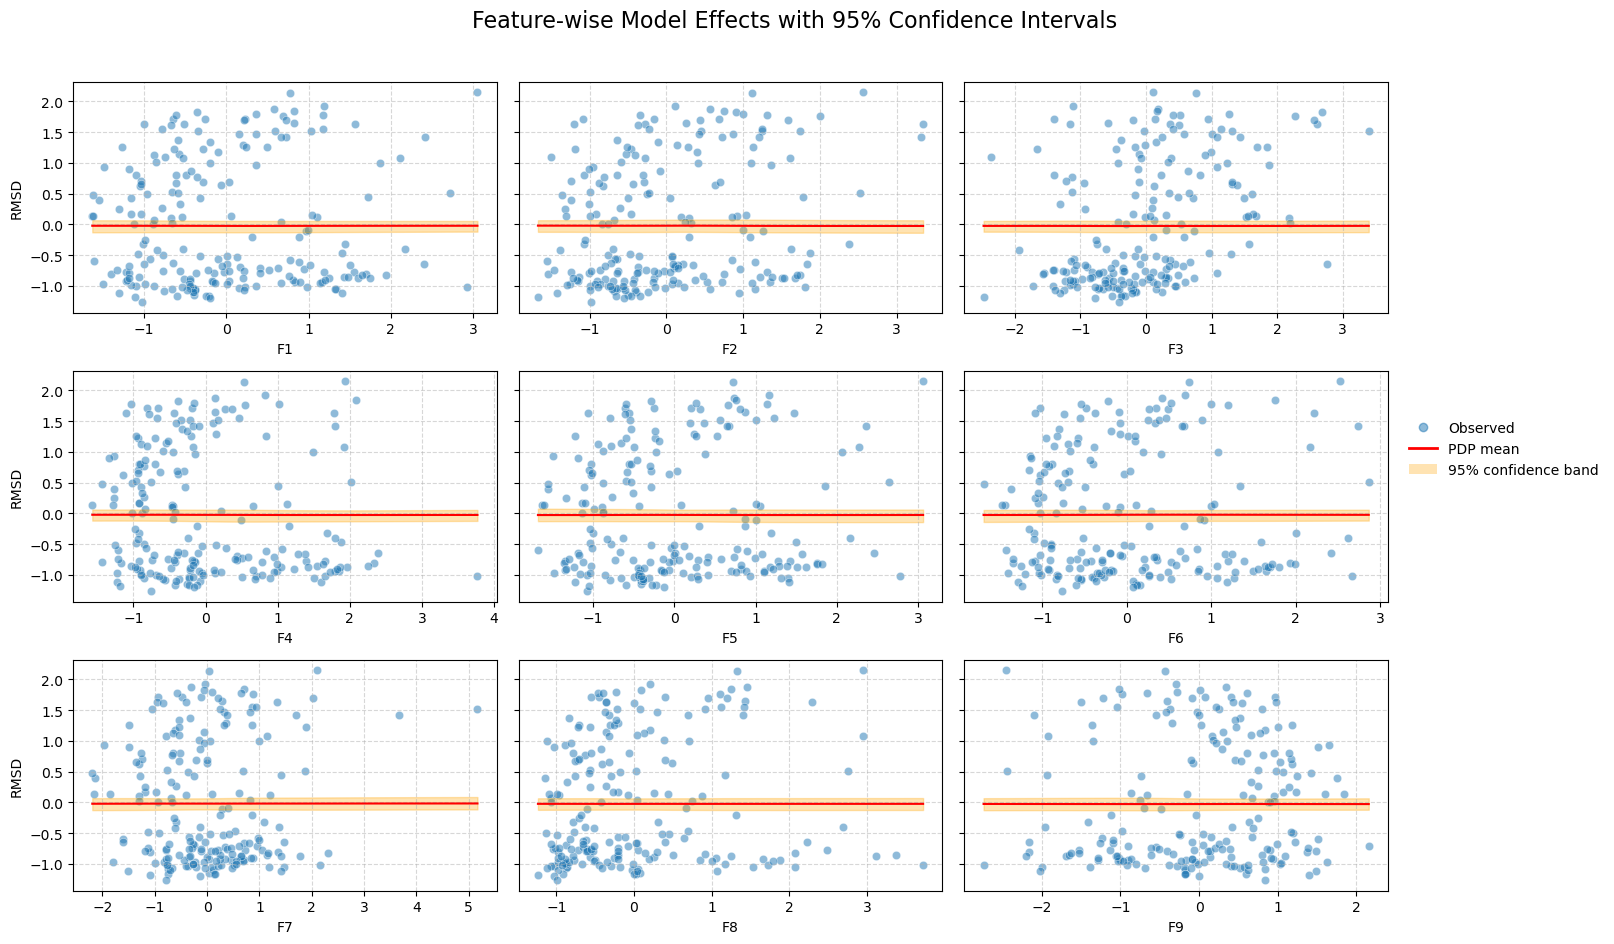

In [6]:
regressor.sketch_model()